# PharmaGuard AI – Pharmaceutical Demand Intelligence

**Dataset:** Real pharmaceutical sales data (2014–2019) from a pharmacy in Slovenia
**Drug Categories:**
- **M01AB** – Anti-inflammatory / antirheumatic products
- **M01AE** – Propionic acid derivatives (e.g. Ibuprofen)
- **N02BA** – Salicylic acid and derivatives (e.g. Aspirin)
- **N02BE** – Anilides (e.g. Paracetamol)
- **N05B** – Anxiolytics
- **N05C** – Hypnotics and sedatives
- **R03** – Drugs for obstructive airway diseases
- **R06** – Antihistamines

**Analysis Framework:** KPIs → Trends → Drivers → Risk → Opportunity → Action

In [2]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.cluster import KMeans
warnings.filterwarnings("ignore")

OUT = "outputs"
os.makedirs(OUT, exist_ok=True)

DRUGS = ["M01AB","M01AE","N02BA","N02BE","N05B","N05C","R03","R06"]
try:
    plt.style.use("seaborn-v0_8-darkgrid")
except OSError:
    plt.style.use("ggplot")
sns.set_palette("tab10")
plt.rcParams.update({"figure.dpi":120,"savefig.bbox":"tight","savefig.facecolor":"white"})
print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Data Loading & Inspection

In [4]:
daily   = pd.read_csv('IBMDataset/salesdaily.csv',  parse_dates=['datum'])
hourly  = pd.read_csv('IBMDataset/saleshourly.csv', parse_dates=['datum'])
weekly  = pd.read_csv('IBMDataset/salesweekly.csv', parse_dates=['datum'])
monthly = pd.read_csv('IBMDataset/salesmonthly.csv', parse_dates=['datum'])

# Remove all-zero gap rows
for df in [daily, monthly, weekly, hourly]:
    df.drop(df[df[DRUGS].sum(axis=1)==0].index, inplace=True)

monthly['Year']  = monthly['datum'].dt.year
monthly['Month'] = monthly['datum'].dt.month
daily['Year']    = daily['datum'].dt.year
daily['Month']   = daily['datum'].dt.month

print('=== DAILY ===')  
print(f'Shape: {daily.shape}')
print('=== MONTHLY ===') 
print(f'Shape: {monthly.shape}')

=== DAILY ===
Shape: (2080, 13) | 2014-01-02 to 2019-10-08
=== HOURLY ===
Shape: (26588, 13) | 2014-01-02 to 2019-10-08
=== WEEKLY ===
Shape: (302, 9) | 2014-01-05 to 2019-10-13
=== MONTHLY ===
Shape: (70, 11) | 2014-01-31 to 2019-10-31


## 2. KPI Analysis

In [6]:
totals      = monthly[DRUGS].sum().sort_values(ascending=False)
monthly_avg = monthly[DRUGS].mean()
cv          = (monthly[DRUGS].std() / monthly[DRUGS].mean() * 100).round(2)
kpi_df = pd.DataFrame({'Total Sales': totals,
                       'Monthly Avg': monthly_avg.reindex(totals.index).round(2),
                       'CV%':         cv.reindex(totals.index),
                       'Market Share%': (totals/totals.sum()*100).round(2)})
kpi_df.to_csv('outputs/kpi_summary.csv')
print(kpi_df.to_string())

       Total Sales  Monthly Avg  Monthly Max  Monthly Min  CV% (Volatility)  Market Share%
N02BE    62477.945       892.54      1856.81          0.0             37.96          49.36
N05B     18348.300       262.12       492.00          1.0             32.45          14.49
R03      11737.250       167.68       386.00          0.0             48.77           9.27
M01AB    10499.440       149.99       211.13          0.0             20.99           8.29
M01AE     8156.000       116.51       222.35          0.0             23.94           6.44
N02BA     8051.459       115.02       191.60          0.0             27.17           6.36
R06       6066.380        86.66       213.04          0.0             52.92           4.79
N05C      1249.000        17.84        50.00          0.0             47.53           0.99


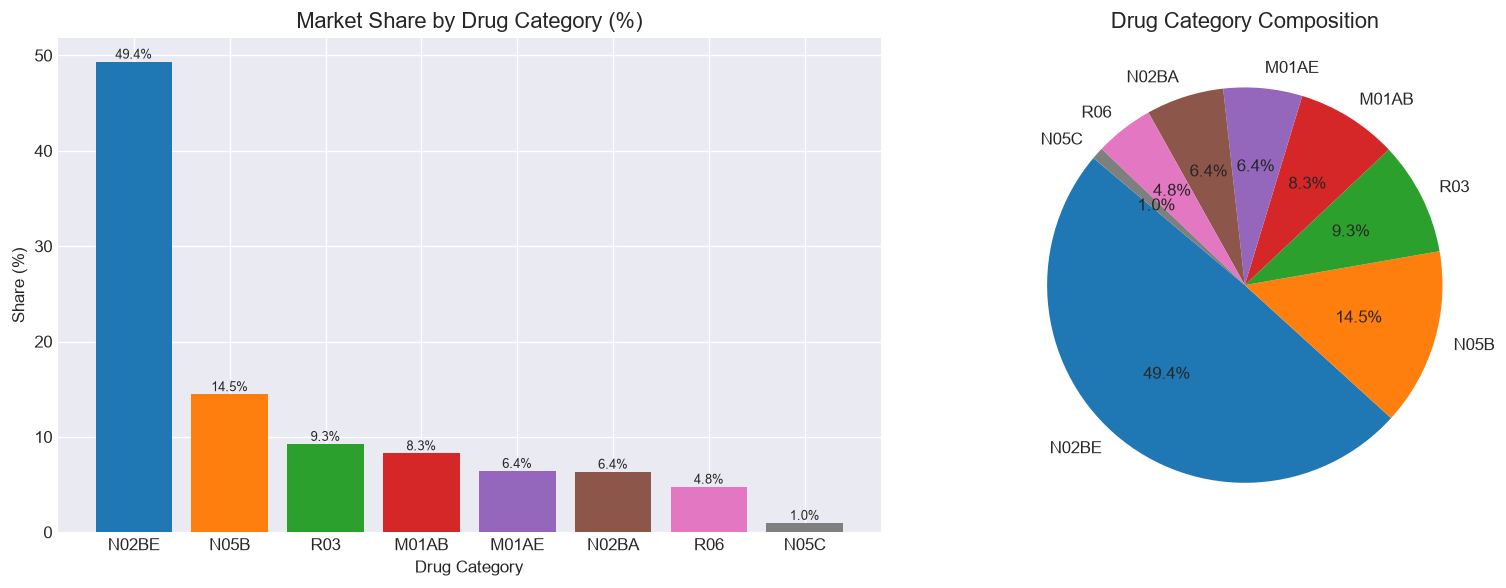

In [7]:
# Market Share pie + bar
fig, axes = plt.subplots(1,2,figsize=(14,5))
...

## 3. Temporal Trends Analysis

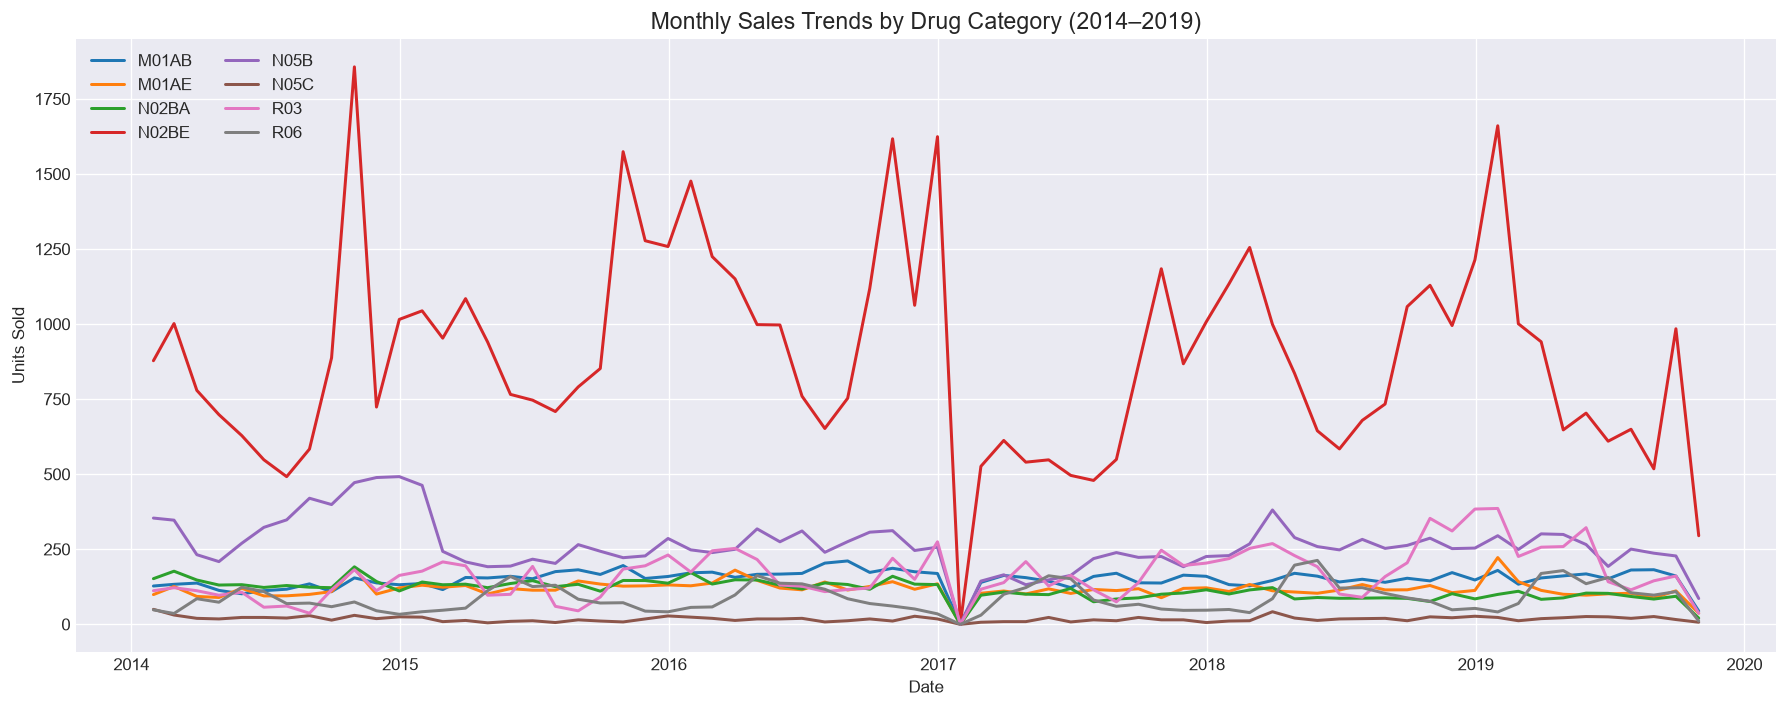

In [9]:
# Monthly trends for all 8 drug categories
...

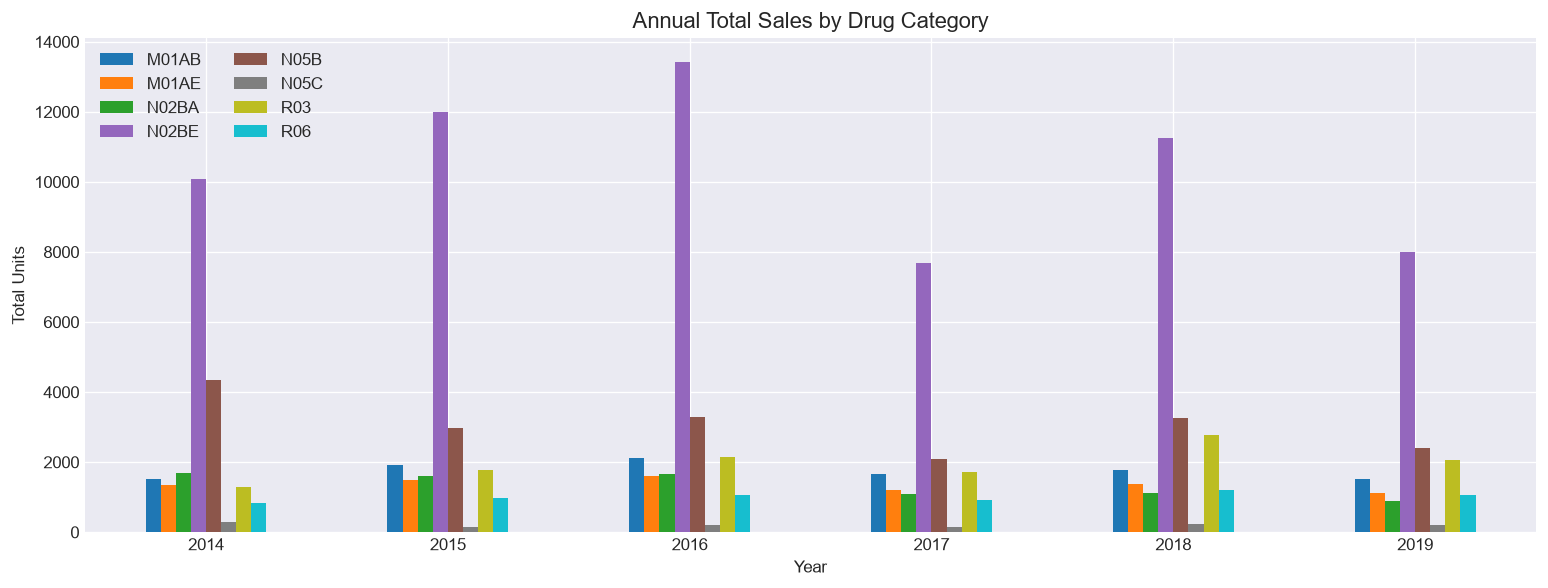

In [10]:
# Annual sales grouped bar
...

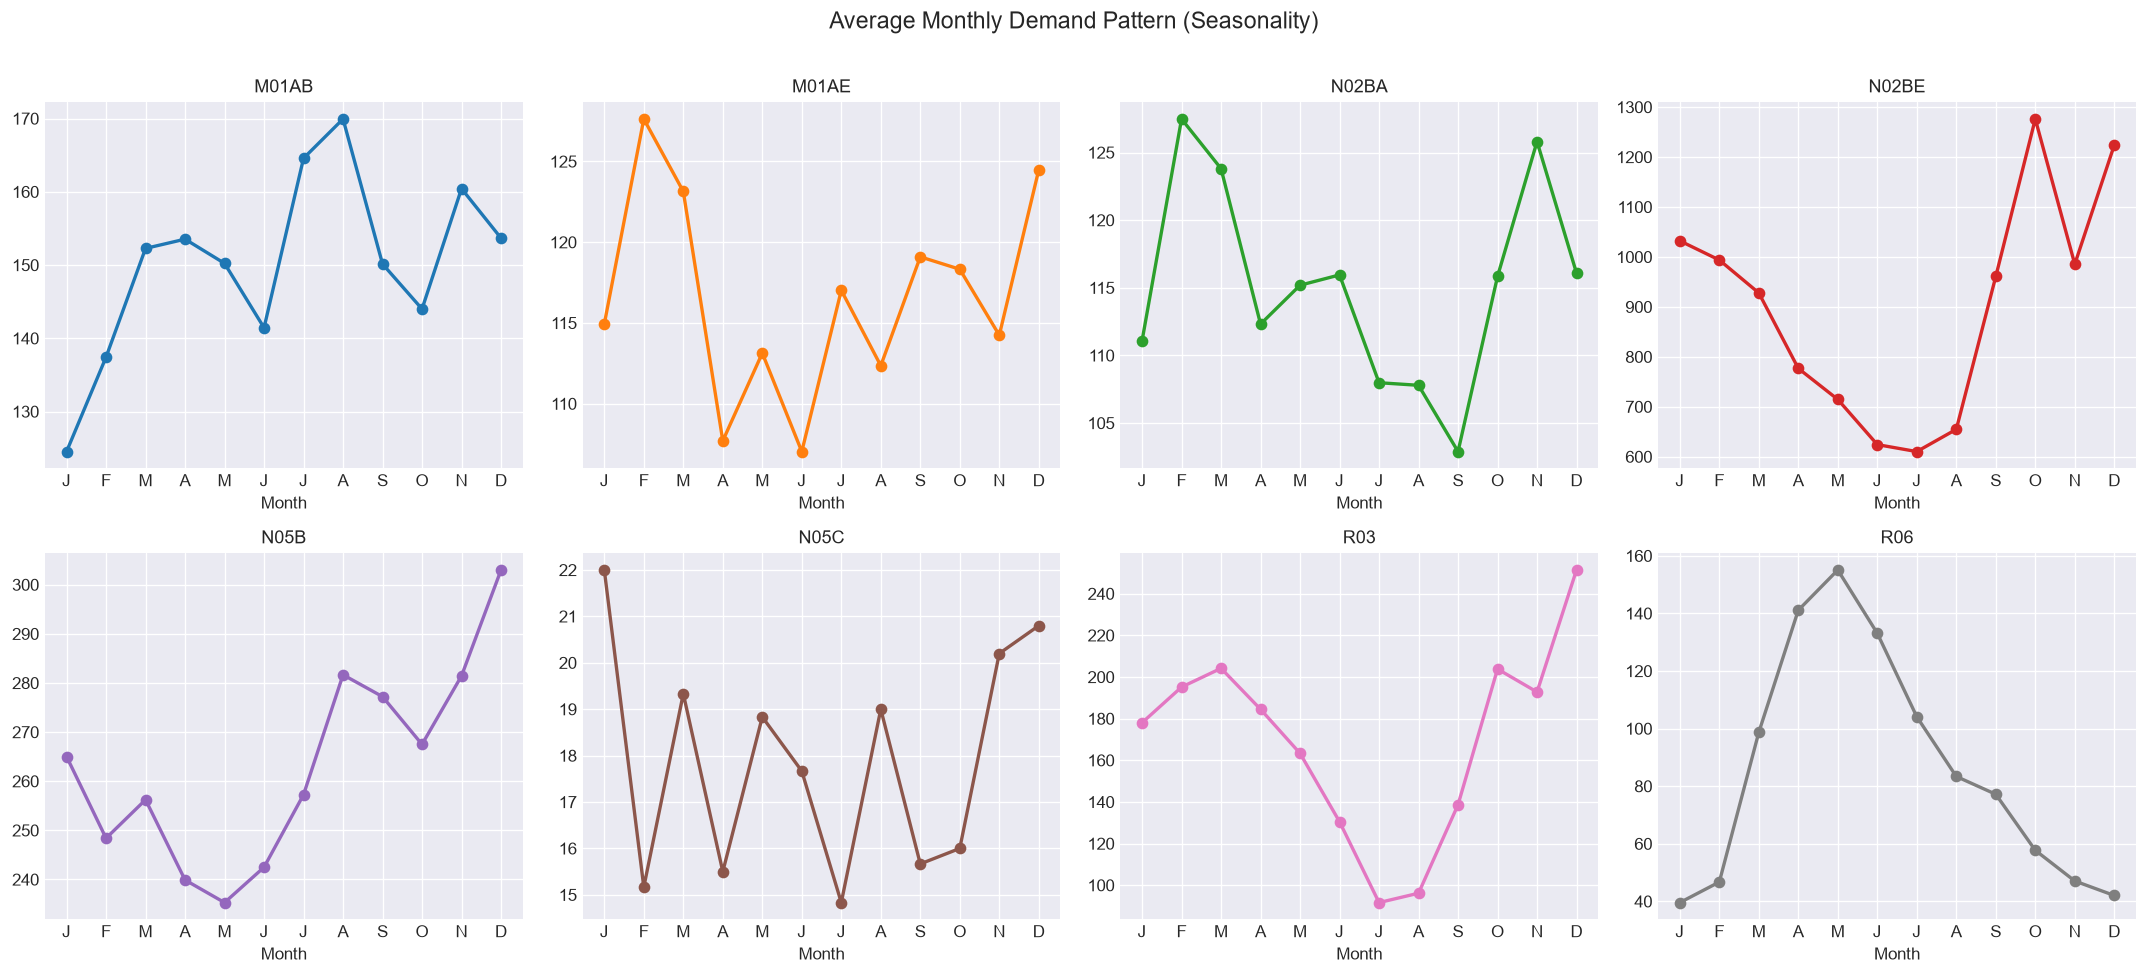

In [11]:
# Seasonality subplots
...

## 4. Demand Drivers Analysis

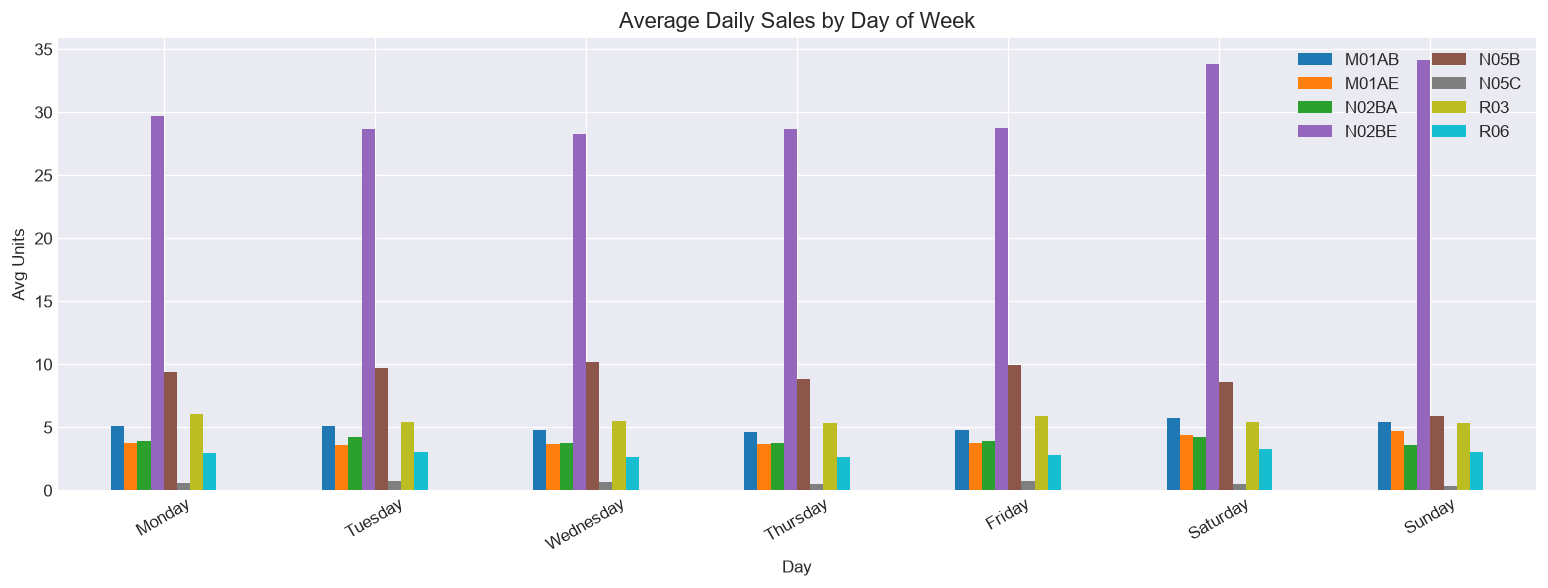

In [13]:
# Day-of-week demand bar chart
...

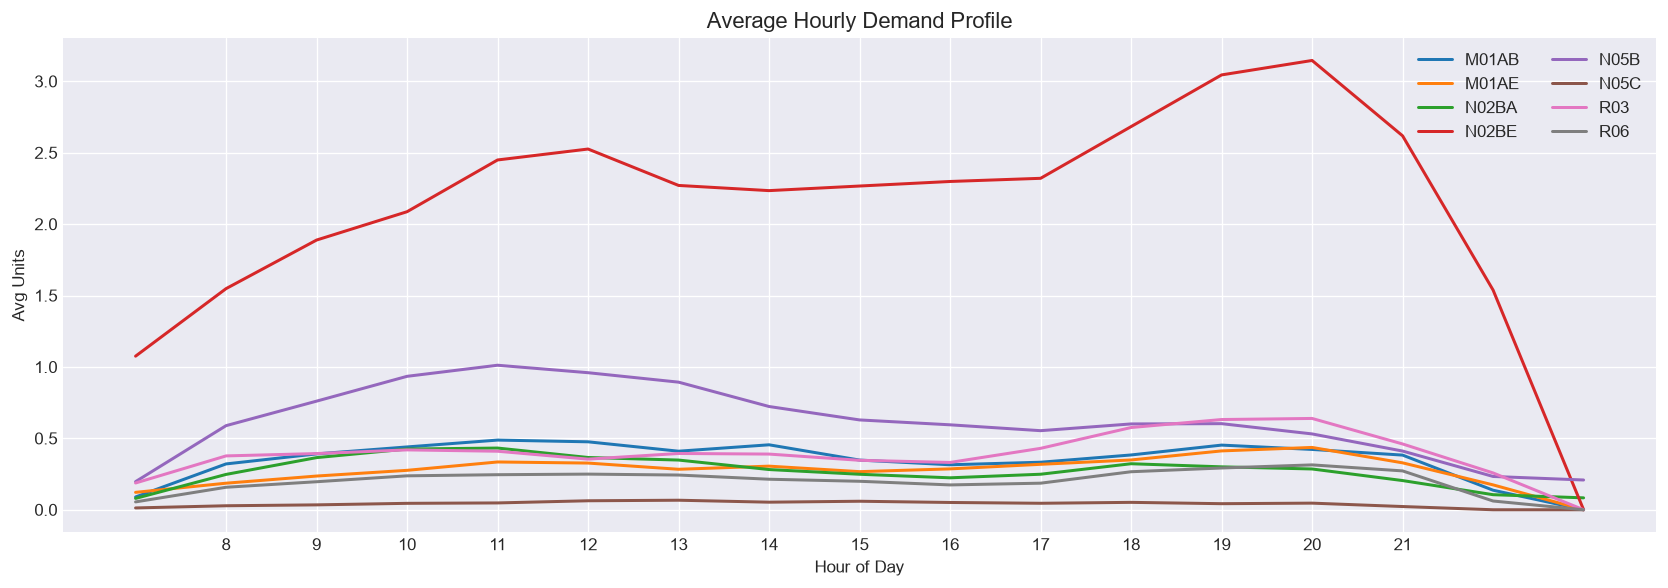

In [14]:
# Hourly demand line chart
...

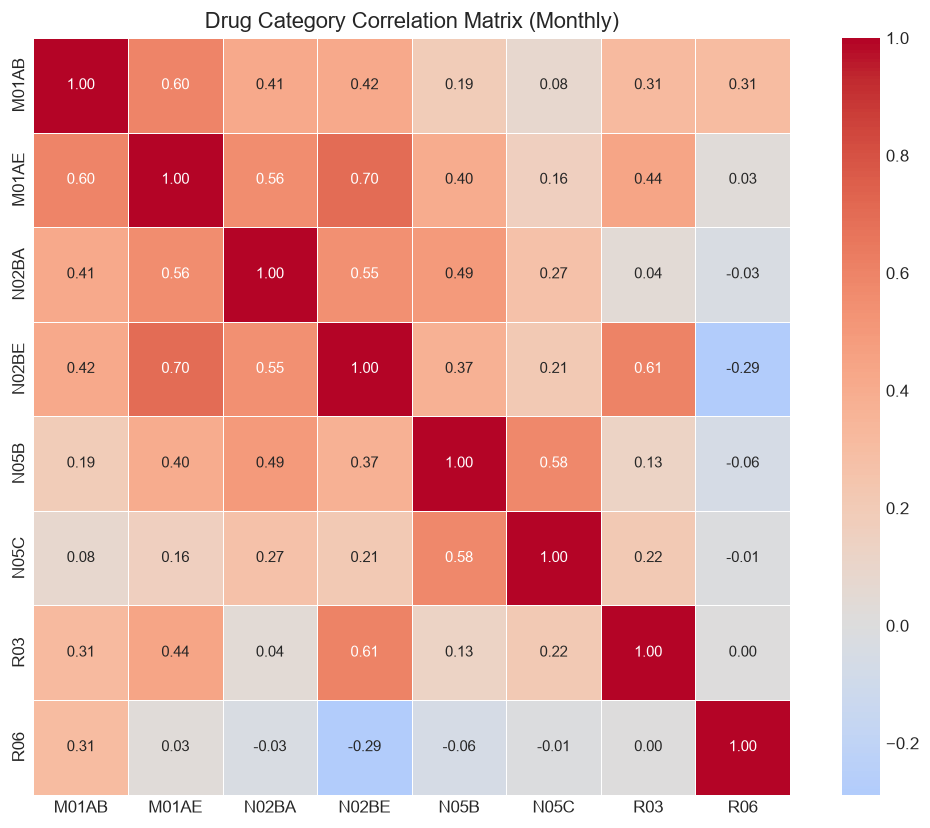

In [15]:
# Correlation heatmap
...

## 5. Anomaly Detection

In [17]:
scaler = StandardScaler()
iso = IsolationForest(contamination=0.05,random_state=42)
monthly['Anomaly'] = iso.fit_predict(scaler.fit_transform(monthly[DRUGS]))
anomalies = monthly[monthly['Anomaly']==-1]
print(anomalies[['datum']+DRUGS].to_string())

Isolation Forest: 4 anomalous months detected
     datum  M01AB  M01AE  N02BA   N02BE  N05B  N05C   R03   R06
2014-10-31 154.75 185.24 191.60 1856.81 472.0  30.0 182.0 74.50
2017-01-31   0.00   0.00   0.00    0.00   1.0   0.0   0.0  0.00
2019-01-31 179.70 222.35  99.70 1660.61 295.2  23.0 386.0 41.30
2019-10-31  44.37  37.30  20.65  295.15  86.0   7.0  37.0 11.13


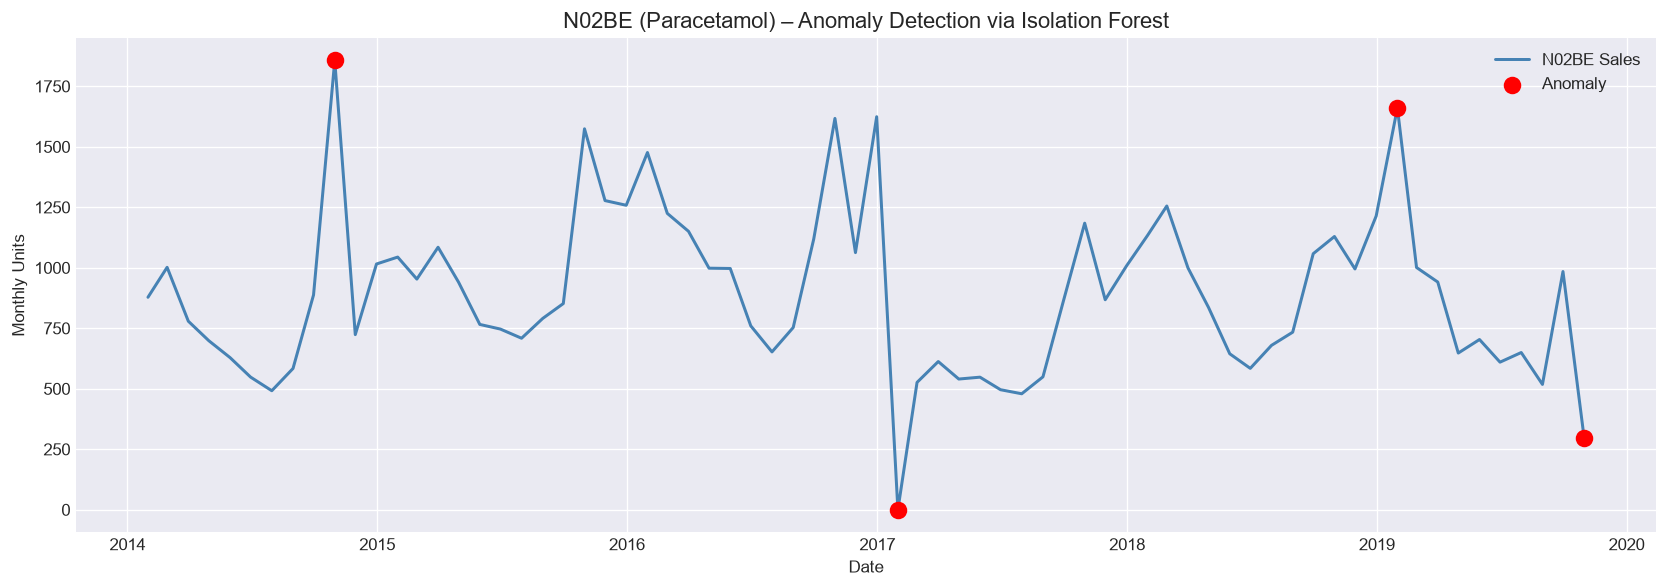

In [18]:
# Anomaly overlay chart for N02BE
...

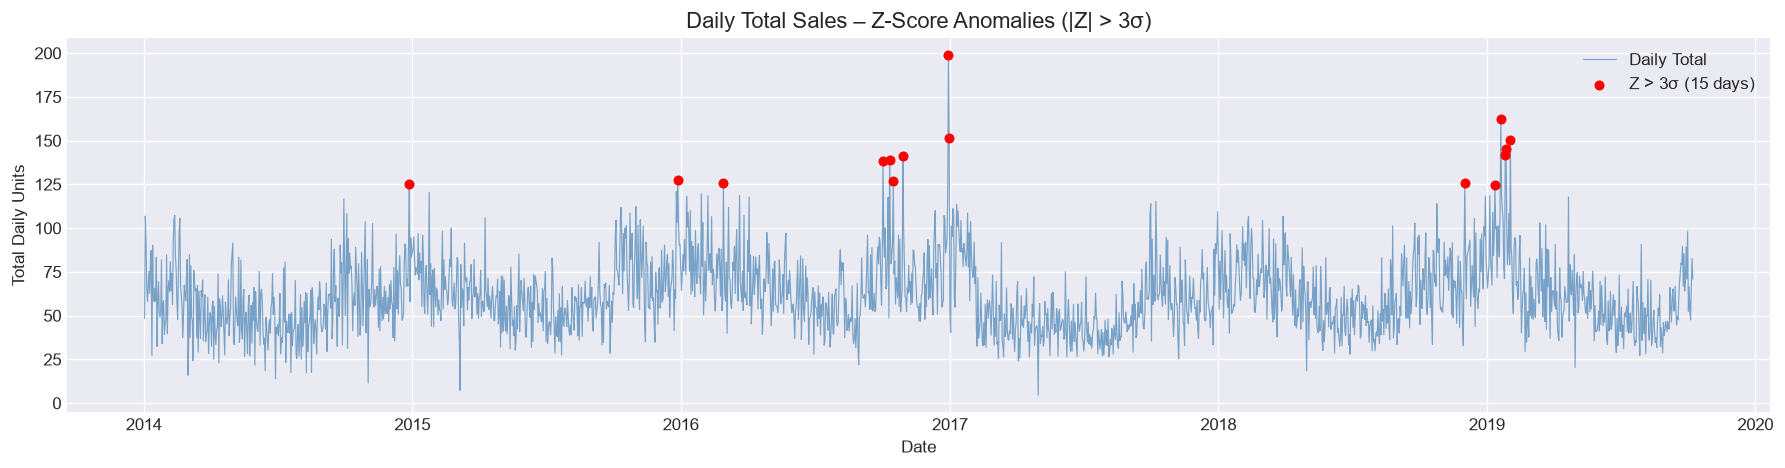

In [19]:
# Z-score daily anomaly chart
...

## 6. Demand Forecasting (Linear Trend + Moving Average)

In [21]:
# Linear regression forecast – all drugs, 6-month holdout
for drug in DRUGS:
    df_fc = monthly[['datum',drug]].copy(); df_fc['t']=range(len(df_fc))
    m = LinearRegression().fit(df_fc.iloc[:-6][['t']], df_fc.iloc[:-6][drug])
    ...

       Slope (units/month)  Intercept  R² (train)  MAE (6-mo test)       Trend
Drug                                                                          
M01AB                0.297     140.83       0.035            29.26    ↑ Upward
M01AE                0.091     116.16       0.004            32.27    ↑ Upward
N02BA               -1.043     150.86       0.426            20.97  ↓ Downward
N02BE                0.594     898.75       0.001           326.50    ↑ Upward
N05B                -1.378     310.42       0.090            43.65  ↓ Downward
N05C                -0.066      19.71       0.020             7.39  ↓ Downward
R03                  2.408      93.13       0.304           124.53    ↑ Upward
R06                  0.485      69.93       0.039            32.65    ↑ Upward


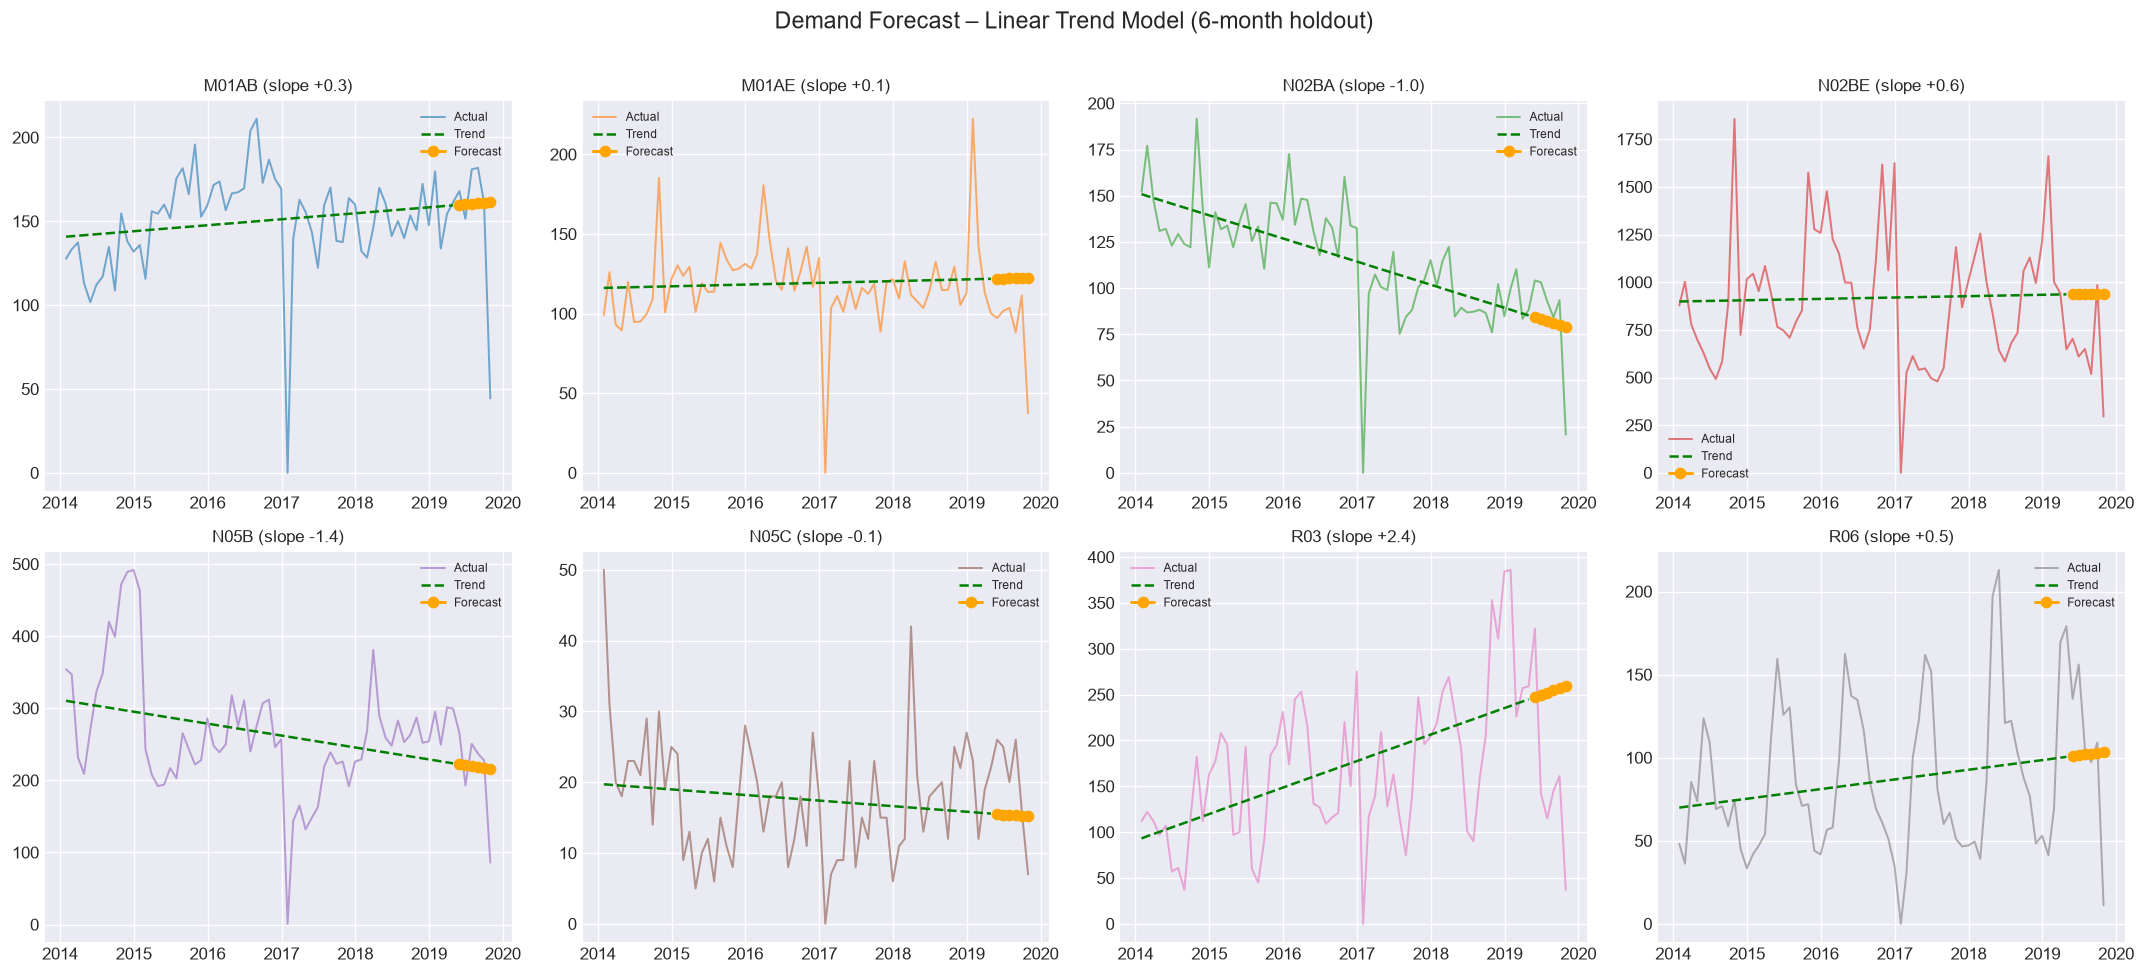

In [22]:
# Forecast subplots for all 8 drugs
...

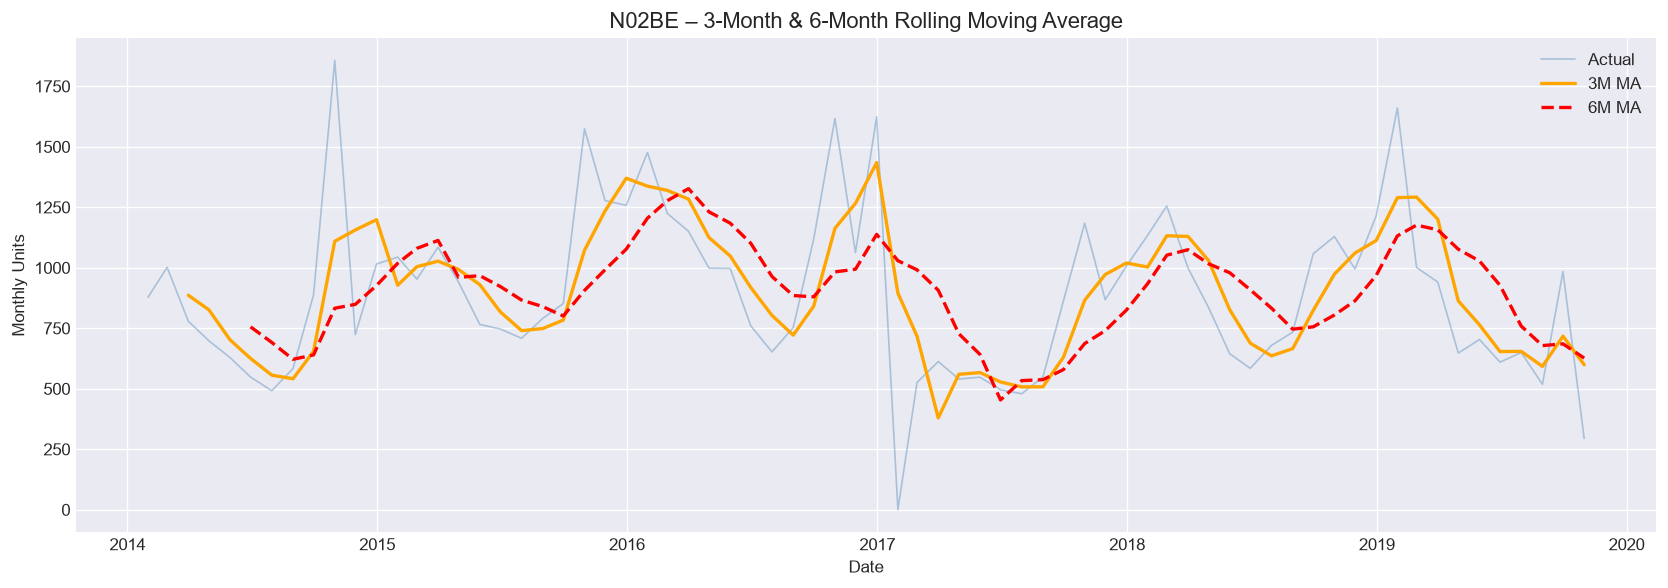

In [23]:
# Rolling MA for N02BE
...

## 7. Risk Analysis

In [25]:
# Risk CV calculation
...

       CV (%) Risk Level
Drug                    
R06     52.92       HIGH
R03     48.77       HIGH
N05C    47.53       HIGH
N02BE   37.96       HIGH
N05B    32.45       HIGH
N02BA   27.17     MEDIUM
M01AE   23.94     MEDIUM
M01AB   20.99     MEDIUM


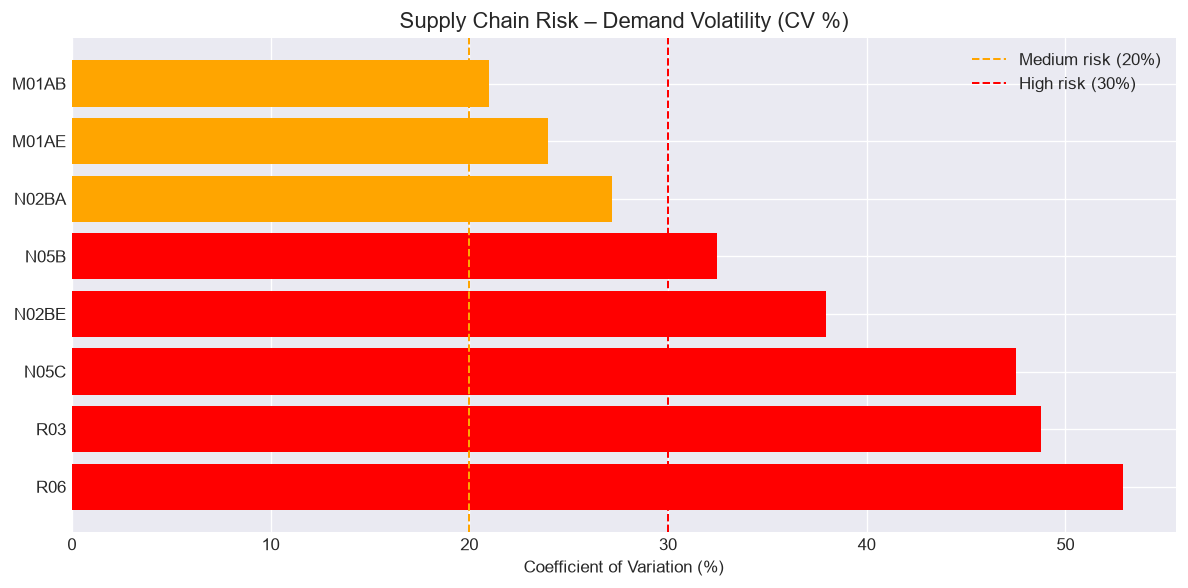

In [26]:
# Risk CV horizontal bar
...

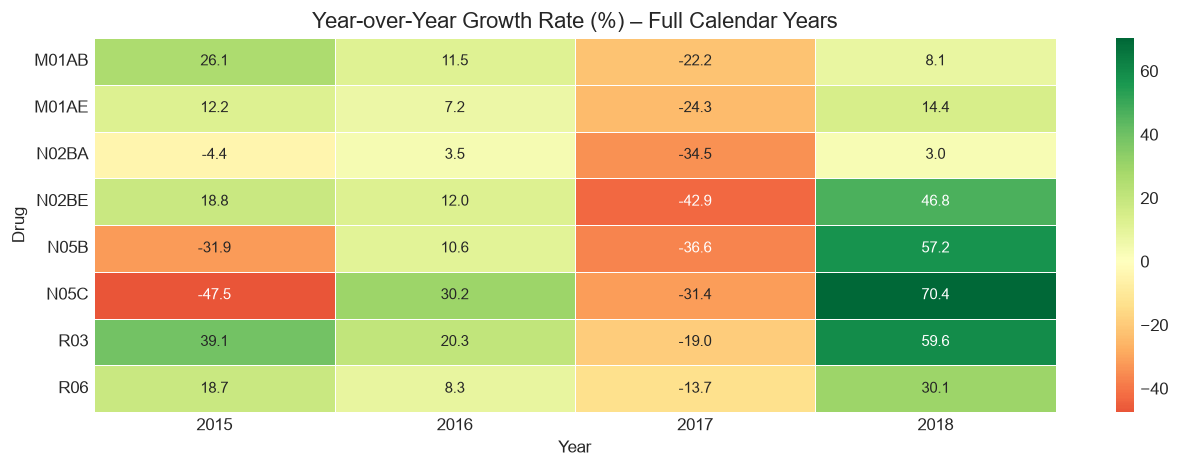

In [27]:
# YoY growth heatmap
...

## 8. Opportunity Analysis

In [29]:
# Growth opportunity 2014 vs 2018
...

       Avg 2014  Avg 2018  Growth %
R03      106.42    230.42    116.52
R06       69.02     99.73     44.49
M01AB    125.90    148.91     18.28
N02BE    841.21    938.64     11.58
M01AE    111.13    115.80      4.20
N05C      25.25     20.17    -20.13
N05B     362.92    272.18    -25.00
N02BA    140.27     93.65    -33.24


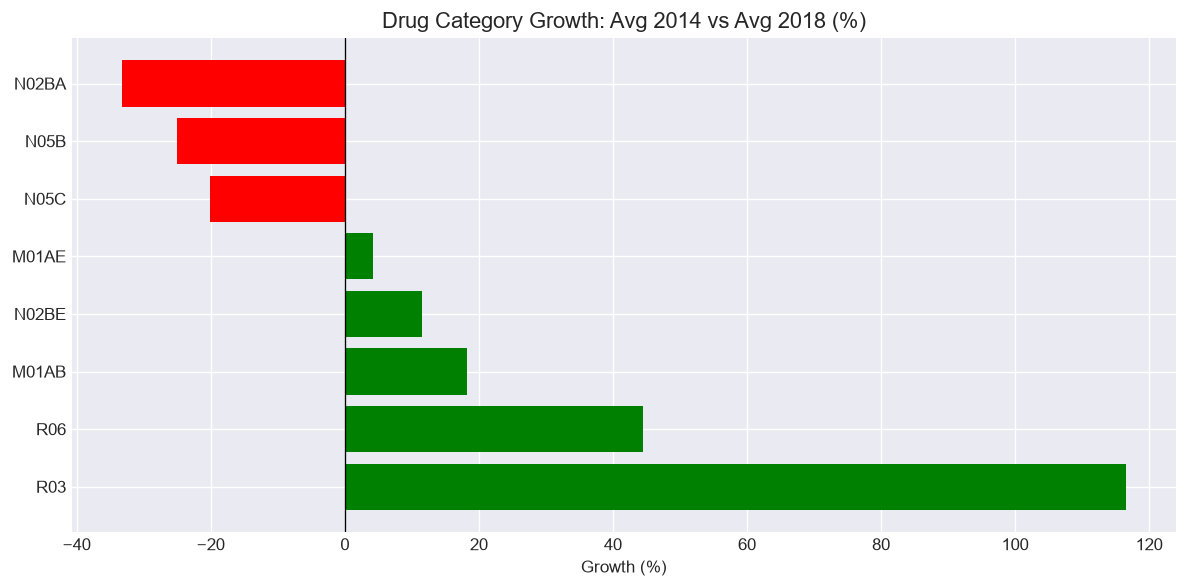

In [30]:
# Growth opportunity horizontal bar
...

In [31]:
# Peak demand month per drug
...

      Peak Month  Peak Avg Units
Drug                            
M01AB        Aug          169.95
M01AE        Feb          127.63
N02BA        Feb          127.48
N02BE        Oct         1276.20
N05B         Dec          303.00
N05C         Jan           22.00
R03          Dec          251.40
R06          May          155.09


## 9. AI Demand Clustering (K-Means)

In [33]:
# K-Means clustering on seasonal demand profile
...

         Cluster  Total Sales   CV %
Drug                                
M01AB  Cluster A      10499.4  20.99
M01AE  Cluster A       8156.0  23.94
N02BA  Cluster A       8051.5  27.17
N02BE  Cluster B      62477.9  37.96
N05B   Cluster C      18348.3  32.45
N05C   Cluster A       1249.0  47.53
R03    Cluster A      11737.2  48.77
R06    Cluster A       6066.4  52.92


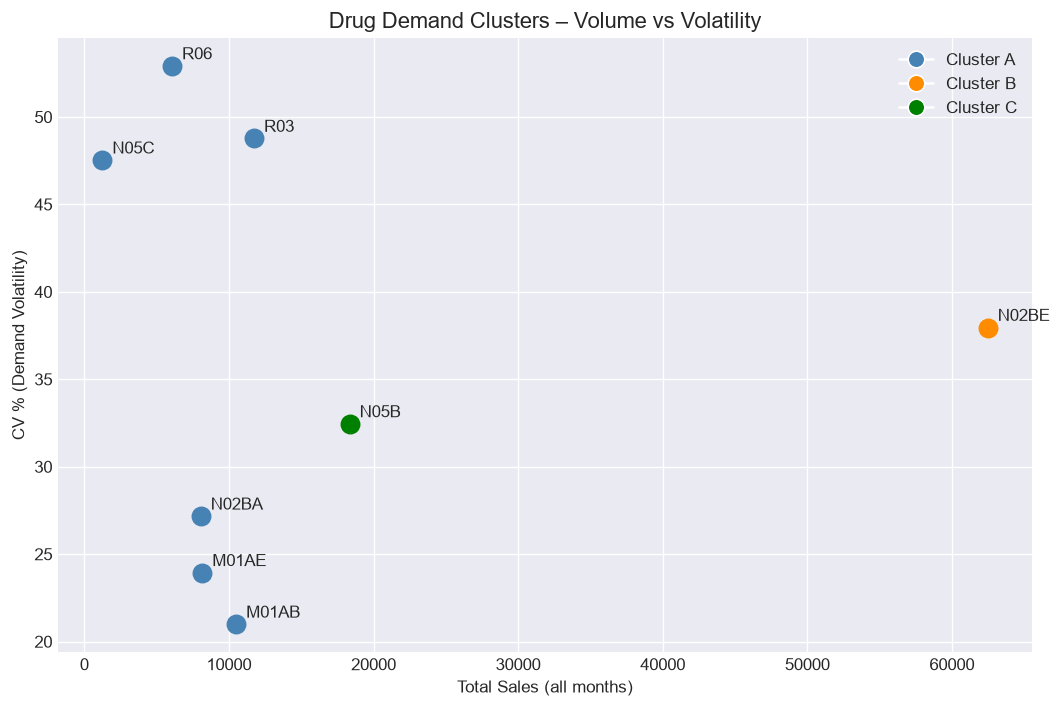

In [34]:
# Cluster scatter
...

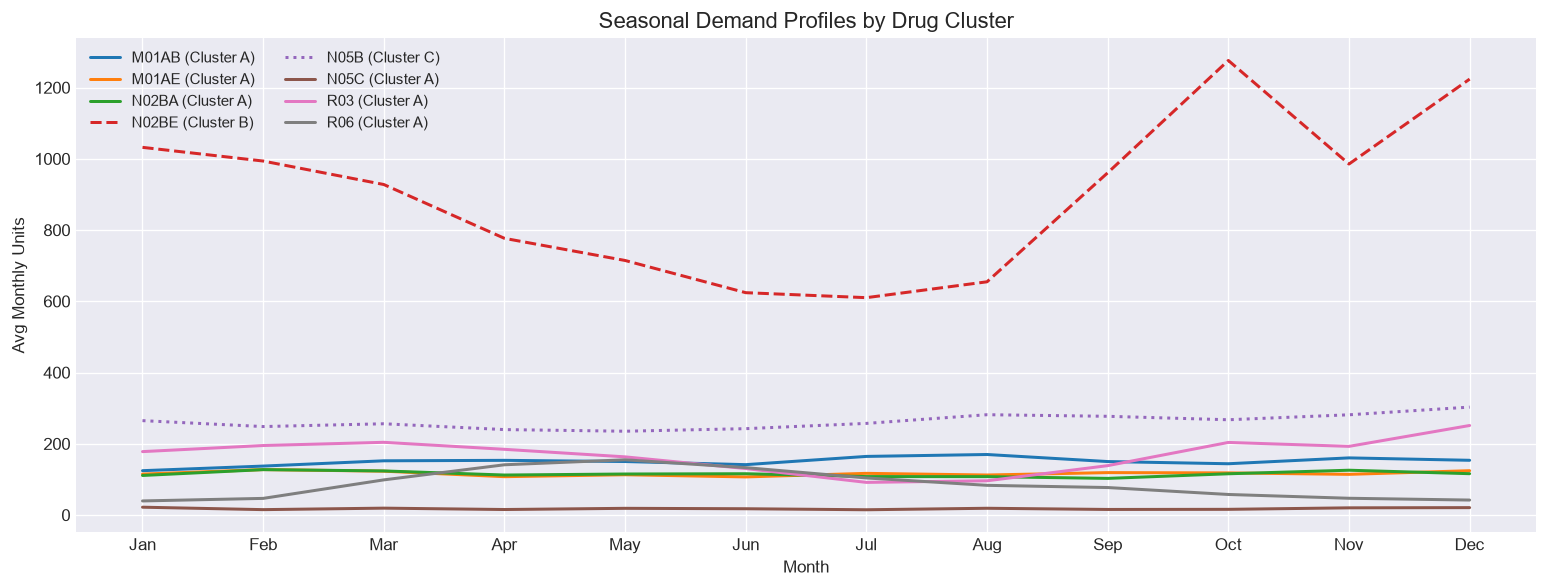

In [35]:
# Seasonal profiles colored by cluster
...

## 10. AI Insights & Key Findings Summary

In [37]:
# Print AI summary
print(summary_str)

PHARMAGUARD AI – KEY FINDINGS

📊 KPIs:
  • Highest volume drug : N02BE (62478 total units, 49.4% share)
  • Most volatile drug  : R06 (CV=52.9%) → HIGH supply risk
  • Most stable drug    : M01AB (CV=21.0%) → LOW supply risk

📈 Trends:
  • Fastest growing (2014→2018): R03 (+116.5%)
  • Declining category          : N05C, N05B, N02BA

⚠️  Risks:
  • High supply-chain risk (CV>30%): R06, R03, N05C, N02BE, N05B
  • Anomalous months (IsoForest)   : 4 months
  • Z-score daily anomalies (|Z|>3): 15 days

💡 Opportunities:
  • N02BE peaks in October – pre-stock 20-30% above avg by September
  • R06 antihistamines peak in spring – Q1 pre-season procurement
  • M01AB/M01AE showing sustained growth – expand supplier contracts
  • N05B anxiolytics trending upward – growing mental health demand

🎯 Actions:
  1. Build safety stock for HIGH-CV drugs (N05C, R06) before peak months
  2. Investigate Oct 2014 N02BE spike (1856 units – nearly 2× avg)
  3. Switch N05C hypnotics to JIT ordering (low volume,

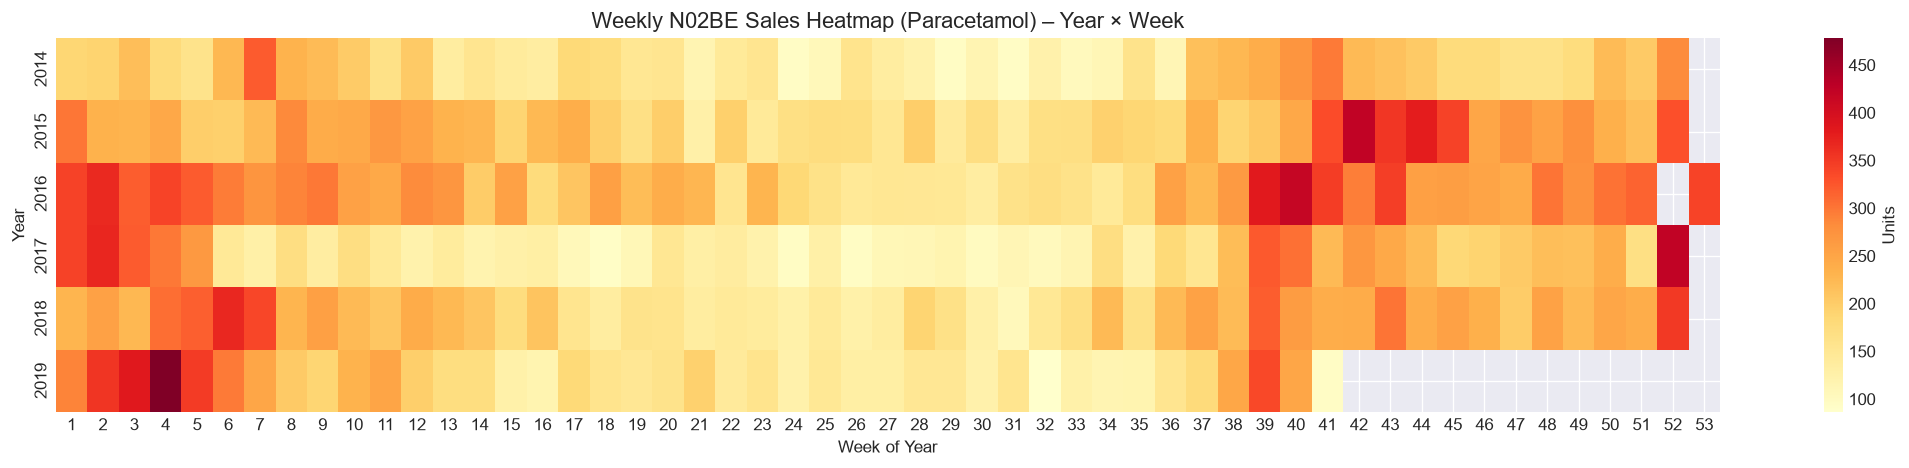

In [38]:
# Weekly heatmap N02BE
...